In [2]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.8 MB/s eta 0:00:00


In [11]:

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np
from faker import Faker
from random import choice, randint, uniform
from datetime import datetime, timedelta

fake = Faker()

np.random.seed(42)

n = 100

diseases = [
    "Hypertension",
    "Diabetes",
    "Asthma",
    "COPD",
    "Heart Disease",
    "Pneumonia",
    "COVID-19",
    "Kidney Disease",
    "Stroke",
    "Healthy"
]

rows = []

start_time = datetime(2025,1,1,8,0,0)

for i in range(1, n+1):

    disease = choice(diseases)

    age = randint(18,85)

    gender = choice(["Male","Female"])

    hr = randint(60,120)
    spo2 = randint(88,100)
    systolic = randint(100,180)
    diastolic = randint(60,110)
    temp = round(uniform(36.0,39.5),1)
    rr = randint(12,28)
    bmi = round(uniform(18,38),1)

    fall = choice(["Yes","No"])

    accuracy = randint(95,100)

    hr_alert = "High" if hr > 100 else "Normal"
    spo2_alert = "Low" if spo2 < 92 else "Normal"
    bp_alert = "High" if systolic > 140 else "Normal"
    temp_alert = "Fever" if temp >= 37.8 else "Normal"

    timestamp = start_time + timedelta(minutes=i)

    rows.append({
        "patient_id": i,
        "patient_name": fake.name(),
        "age": age,
        "gender": gender,
        "disease": disease,
        "heart_rate": hr,
        "spO2_level": spo2,
        "systolic_blood_pressure": systolic,
        "diastolic_blood_pressure": diastolic,
        "body_temperature": temp,
        "respiratory_rate": rr,
        "bmi": bmi,
        "fall_detection": fall,
        "data_accuracy": accuracy,
        "heart_rate_alert": hr_alert,
        "spO2_level_alert": spo2_alert,
        "blood_pressure_alert": bp_alert,
        "temperature_alert": temp_alert,
        "timestamp": timestamp
    })

df = pd.DataFrame(rows)

df.head()

,patient_id,patient_name,age,gender,disease,heart_rate,spO2_level,systolic_blood_pressure,diastolic_blood_pressure,body_temperature,respiratory_rate,bmi,fall_detection,data_accuracy,heart_rate_alert,spO2_level_alert,blood_pressure_alert,temperature_alert,timestamp
0,1,Cassandra Adams,42,Female,Pneumonia,83,93,160,64,39.4,18,20.9,No,95,Normal,Normal,High,Fever,2025-01-01 08:01:00
1,2,William Garcia,37,Male,Pneumonia,104,90,100,104,39.3,28,34.2,No,98,High,Low,Normal,Fever,2025-01-01 08:02:00
2,3,Mr. Nicholas Calhoun,74,Male,Hypertension,109,98,176,104,38.7,13,29.2,No,99,High,Normal,High,Fever,2025-01-01 08:03:00
3,4,Michael Montoya,75,Female,Heart Disease,73,94,120,70,36.8,22,28.0,No,100,Normal,Normal,Normal,Normal,2025-01-01 08:04:00
4,5,Brian Vasquez,80,Male,Hypertension,91,98,124,66,39.2,20,25.0,No,95,Normal,Normal,Normal,Fever,2025-01-01 08:05:00


In [4]:
df.shape

(100, 19)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   patient_id                100 non-null    int64         
 1   patient_name              100 non-null    object        
 2   age                       100 non-null    int64         
 3   gender                    100 non-null    object        
 4   disease                   100 non-null    object        
 5   heart_rate                100 non-null    int64         
 6   spO2_level                100 non-null    int64         
 7   systolic_blood_pressure   100 non-null    int64         
 8   diastolic_blood_pressure  100 non-null    int64         
 9   body_temperature          100 non-null    float64       
 10  respiratory_rate          100 non-null    int64         
 11  bmi                       100 non-null    float64       
 12  fall_detection         

In [6]:
df.describe()

,patient_id,age,heart_rate,spO2_level,systolic_blood_pressure,diastolic_blood_pressure,body_temperature,respiratory_rate,bmi,data_accuracy,timestamp
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100
mean,50.500000,51.960000,88.540000,93.850000,139.690000,83.910000,37.846000,20.480000,27.679000,97.660000,2025-01-01 08:50:30
min,1.000000,18.000000,60.000000,88.000000,100.000000,60.000000,36.100000,12.000000,18.300000,95.000000,2025-01-01 08:01:00
25%,25.750000,32.000000,74.750000,90.000000,121.000000,70.750000,36.975000,16.750000,22.625000,96.000000,2025-01-01 08:25:45
50%,50.500000,52.000000,86.000000,94.000000,136.000000,82.000000,37.850000,20.000000,27.950000,98.000000,2025-01-01 08:50:30
75%,75.250000,70.250000,103.250000,97.250000,160.250000,97.000000,38.700000,25.000000,33.150000,99.000000,2025-01-01 09:15:15
max,100.000000,85.000000,120.000000,100.000000,180.000000,110.000000,39.500000,28.000000,37.700000,100.000000,2025-01-01 09:40:00
std,29.011492,21.172652,17.699752,3.870048,23.807178,15.044778,1.014881,4.914378,5.886576,1.712816,NaN


In [7]:
df.to_csv("synthetic_healthcare_dataset_100_patients.csv", index=False)

## Check for Missing values

In [8]:
missing = df.isnull().sum()

missing[missing > 0]

,0


## Check for Duplicate records

In [9]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


## Convert Timestamp

In [10]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   patient_id                100 non-null    int64         
 1   patient_name              100 non-null    object        
 2   age                       100 non-null    int64         
 3   gender                    100 non-null    object        
 4   disease                   100 non-null    object        
 5   heart_rate                100 non-null    int64         
 6   spO2_level                100 non-null    int64         
 7   systolic_blood_pressure   100 non-null    int64         
 8   diastolic_blood_pressure  100 non-null    int64         
 9   body_temperature          100 non-null    float64       
 10  respiratory_rate          100 non-null    int64         
 11  bmi                       100 non-null    float64       
 12  fall_detection         

## Disease Distribution

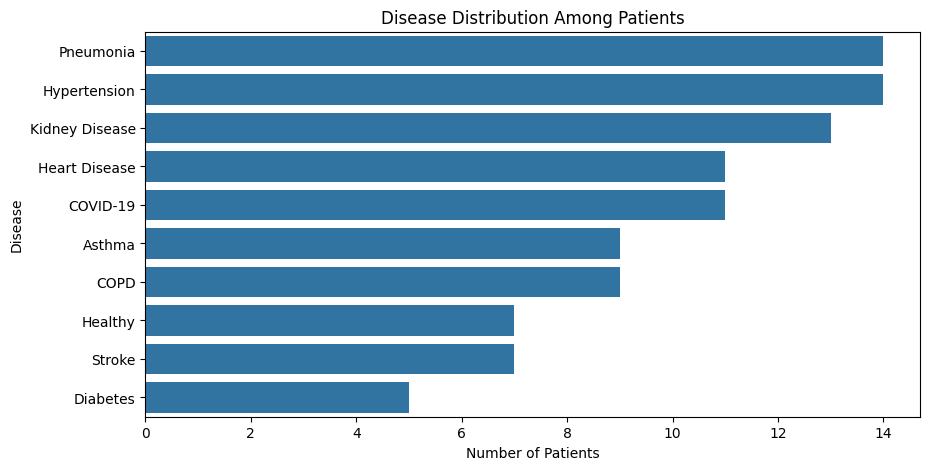

In [12]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="disease",
    order=df["disease"].value_counts().index
)

plt.title(
    "Disease Distribution Among Patients"
)

plt.xlabel("Number of Patients")
plt.ylabel("Disease")

plt.show()

## Age Distribution

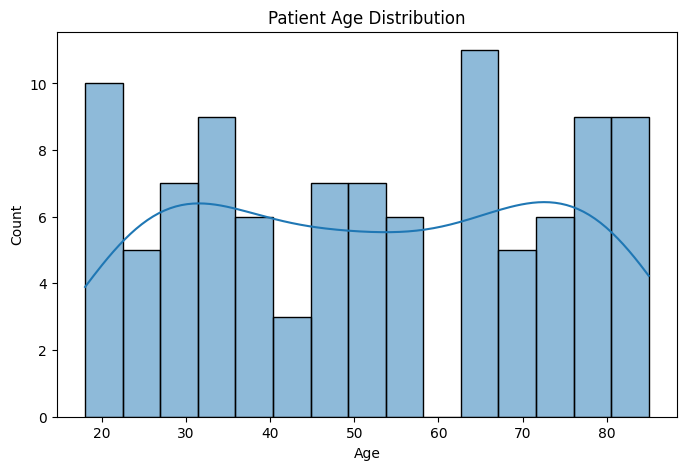

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df.age,
    bins=15,
    kde=True
)

plt.title(
    "Patient Age Distribution"
)

plt.xlabel("Age")

plt.show()

## Gender Distribution

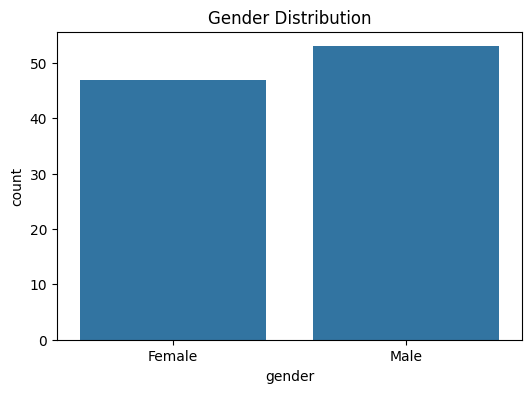

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender"
)

plt.title(
    "Gender Distribution"
)

plt.show()

# Heart Rate Distribution

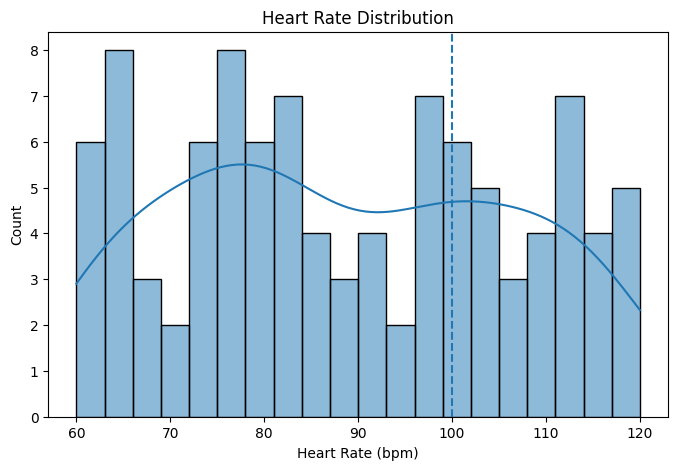

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df.heart_rate,
    bins=20,
    kde=True
)

plt.axvline(
    100,
    linestyle="--"
)

plt.title(
    "Heart Rate Distribution"
)

plt.xlabel(
    "Heart Rate (bpm)"
)

plt.show()

## Disease vs Heart Rate

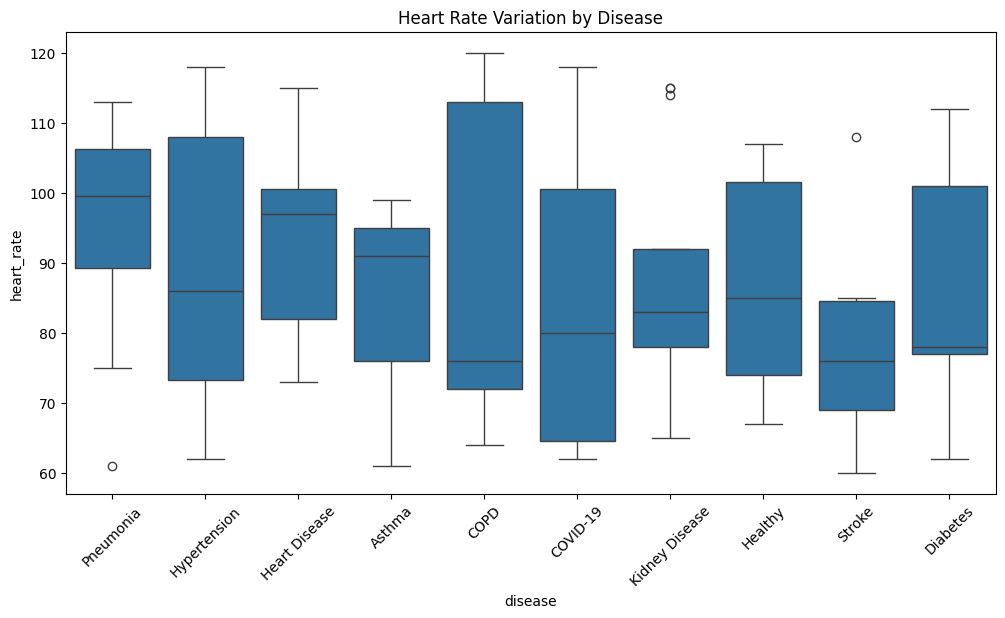

In [16]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="disease",
    y="heart_rate"
)

plt.xticks(
    rotation=45
)

plt.title(
    "Heart Rate Variation by Disease"
)

plt.show()

# Heart Rate Alerts

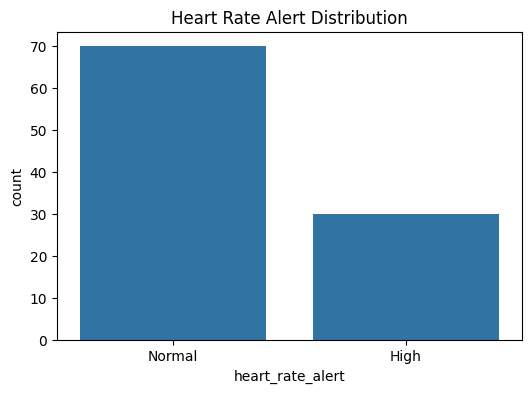

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="heart_rate_alert"
)

plt.title(
    "Heart Rate Alert Distribution"
)

plt.show()

## SpO2 Alerts

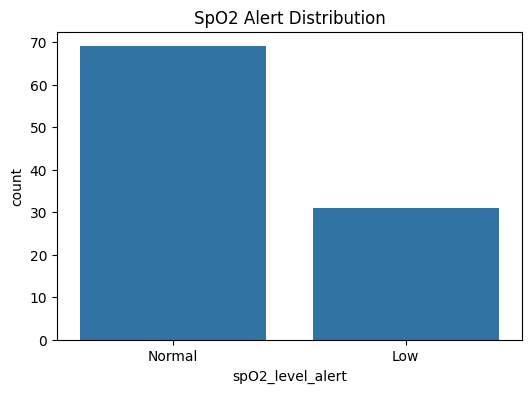

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="spO2_level_alert"
)

plt.title(
    "SpO2 Alert Distribution"
)

plt.show()

## Blood Pressure Alerts

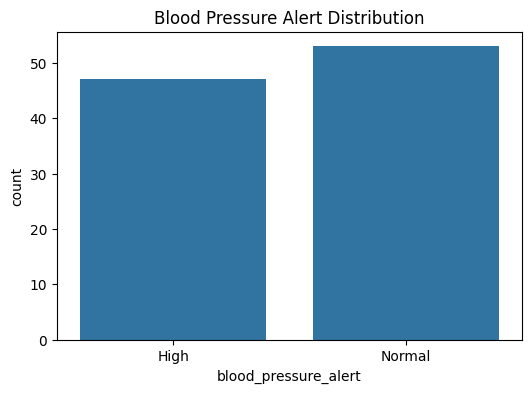

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="blood_pressure_alert"
)

plt.title(
    "Blood Pressure Alert Distribution"
)

plt.show()